In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ml-latest-small.zip to ml-latest-small (1).zip


In [ ]:
!ls

ml-latest-small.zip  sample_data


In [ ]:
!unzip ml-latest-small.zip

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [ ]:
import pandas as pd

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
data = pd.merge(ratings, movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = data[['userId', 'movieId']]
y = data['rating']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.047872279127166


In [ ]:
# Define movie titles for the sample predicted ratings
movie_titles = ["Toy Story (1995)", "Usual Suspects, The (1995)",
                "Grumpier Old Men (1995)", "Heat (1995)",
                "Seven (a.k.a. Se7en) (1995)"]

In [ ]:
# Treat userId and movieId as categorical using One-Hot Encoding
X = pd.get_dummies(data[['userId', 'movieId']])
y = data['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.047872279127166


/tmp/ipykernel_359/358220552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted Rating', y='Movie', data=predicted_ratings, palette='viridis')


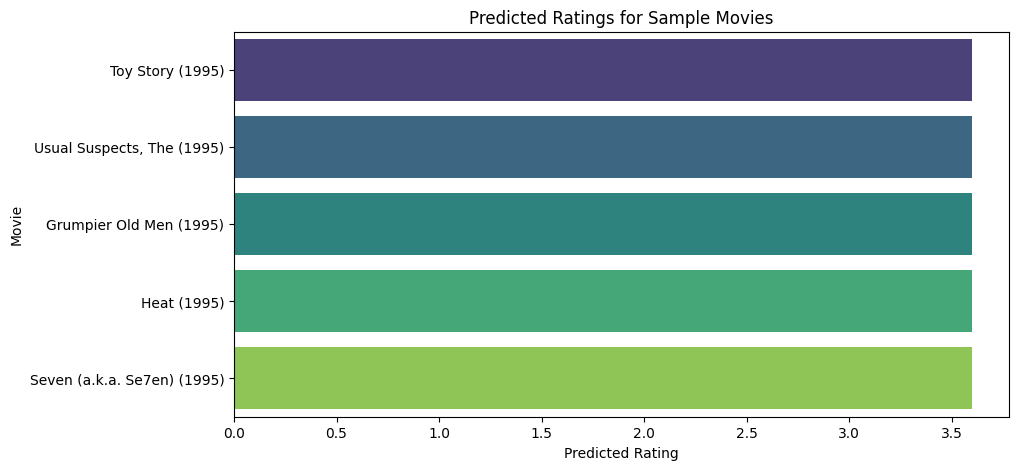

In [ ]:
# Bar plot of predicted ratings
plt.figure(figsize=(10,5))
sns.barplot(x='Predicted Rating', y='Movie', data=predicted_ratings, palette='viridis')
plt.title('Predicted Ratings for Sample Movies')
plt.xlabel('Predicted Rating')
plt.ylabel('Movie')
plt.show()

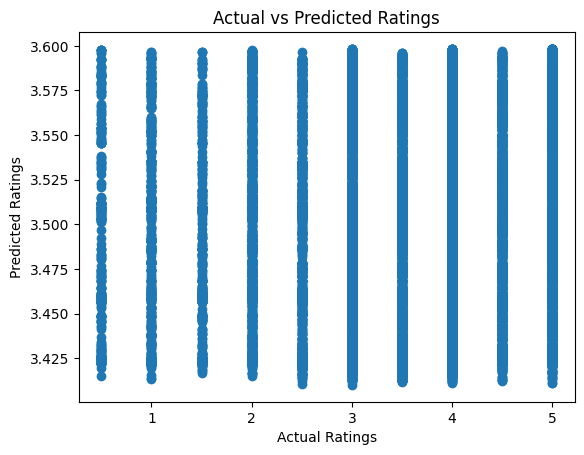

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

In [ ]:
# Step 1: Choose userId and movie title
user_id = 1
movie_name = "Toy Story (1995)"

# Step 2: Get movieId from movies dataframe
movie_id = movies.loc[movies['title'] == movie_name, 'movieId'].values[0]

# Step 3: Predict rating using the trained Linear Regression model
predicted_rating = model.predict([[user_id, movie_id]])[0]

print(f"Predicted rating for user {user_id} on '{movie_name}': {predicted_rating:.2f}")

Predicted rating for user 1 on 'Toy Story (1995)': 3.60


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# List of movies to predict
movies_to_predict = [
    "Toy Story (1995)",
    "Usual Suspects, The (1995)",
    "Grumpier Old Men (1995)",
    "Heat (1995)",
    "Seven (a.k.a. Se7en) (1995)"
]

predictions = []

for movie_name in movies_to_predict:
    movie_id = movies.loc[movies['title'] == movie_name, 'movieId'].values[0]
    pred_rating = model.predict([[1, movie_id]])[0]  # userId = 1
    predictions.append([movie_name, pred_rating])

# Convert to DataFrame for nice display
pred_df = pd.DataFrame(predictions, columns=['Movie', 'Predicted Rating'])
pred_df['Predicted Rating'] = pred_df['Predicted Rating'].round(2)

pred_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Movie,Predicted Rating
0,Toy Story (1995),3.6
1,"Usual Suspects, The (1995)",3.6
2,Grumpier Old Men (1995),3.6
3,Heat (1995),3.6
4,Seven (a.k.a. Se7en) (1995),3.6


In [ ]:
# Display predicted ratings for first 5 movies
predicted_ratings = pd.DataFrame({
    'Movie': movie_titles,
    'Predicted Rating': y_pred[:5]
})

predicted_ratings['Predicted Rating'] = predicted_ratings['Predicted Rating'].round(2)
predicted_ratings.reset_index(inplace=True, drop=True)
predicted_ratings

,Movie,Predicted Rating
0,Toy Story (1995),3.47
1,"Usual Suspects, The (1995)",3.52
2,Grumpier Old Men (1995),3.42
3,Heat (1995),3.59
4,Seven (a.k.a. Se7en) (1995),3.58


/tmp/ipykernel_359/6407756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted Rating', y='Movie', data=predicted_ratings, palette='viridis')


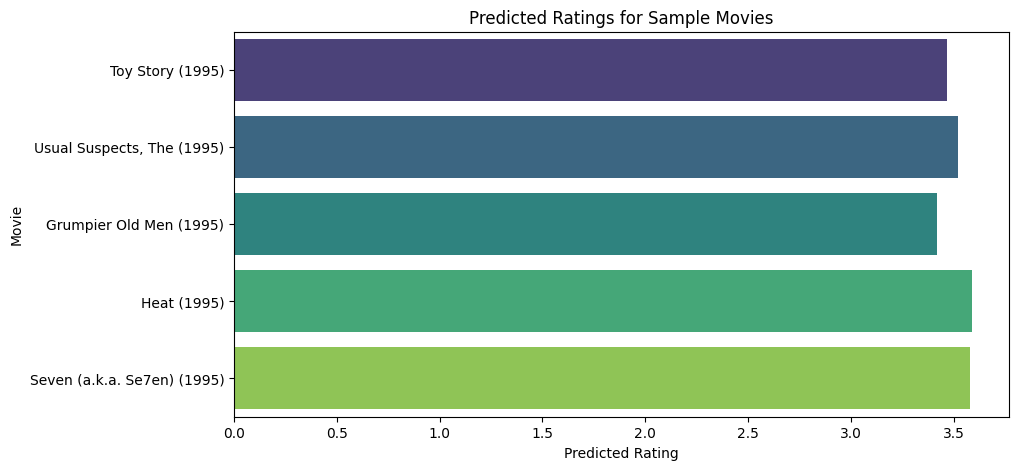

In [ ]:
# Visualize predicted ratings
plt.figure(figsize=(10,5))
sns.barplot(x='Predicted Rating', y='Movie', data=predicted_ratings, palette='viridis')
plt.title('Predicted Ratings for Sample Movies')
plt.xlabel('Predicted Rating')
plt.ylabel('Movie')
plt.show()